# 1. Fetching the Market Data

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set visual style
sns.set_theme(style="whitegrid")

# Define tickers: BP.L (FTSE 100) and XOM (S&P 500)
tickers = ['BP.L', 'XOM']

# Dynamically calculate the trailing 12 months
end_date = datetime.today()
start_date = end_date - timedelta(days=365)

# Format for yfinance (YYYY-MM-DD)
end_str = end_date.strftime('%Y-%m-%d')
start_str = start_date.strftime('%Y-%m-%d')

print(f"Fetching trailing 12 months data for: {tickers}")
print(f"Window: {start_str} to {end_str}...")

# 1. Download the FULL payload first
raw_data_full = yf.download(tickers, start=start_str, end=end_str)

# 2. Inspect the columns and gracefully select the right price data
if 'Adj Close' in raw_data_full.columns:
    raw_data = raw_data_full['Adj Close']
    print("Using 'Adj Close' column.")
elif 'Close' in raw_data_full.columns:
    raw_data = raw_data_full['Close']
    print("Using 'Close' column (yfinance likely auto-adjusted).")
else:
    print("Error: Could not find price columns. Here is what yfinance sent:")
    print(raw_data_full.columns)

print("Data fetched successfully!")

Fetching trailing 12 months data for: ['BP.L', 'XOM']
Window: 2025-05-24 to 2026-05-24...


[*********************100%***********************]  2 of 2 completed

Using 'Close' column (yfinance likely auto-adjusted).
Data fetched successfully!


# 2. Cleaning and Calculating Volatility

In [3]:
print("--- Missing Data Check ---")
print(raw_data.isnull().sum())

# Drop rows where one market was closed (holidays)
clean_data = raw_data.dropna()

# Calculate daily returns (percentage change)
returns = clean_data.pct_change().dropna()

print("\n--- Summary Statistics (Daily Returns) ---")
print(returns.describe())

--- Missing Data Check ---
Ticker
BP.L    4
XOM     6
dtype: int64

--- Summary Statistics (Daily Returns) ---
Ticker        BP.L         XOM
count   245.000000  245.000000
mean      0.001900    0.001893
std       0.017725    0.015350
min      -0.073630   -0.052340
25%      -0.006097   -0.007105
50%       0.002486    0.002985
75%       0.011881    0.012345
max       0.054422    0.040659


# 3. Rendering the Visuals

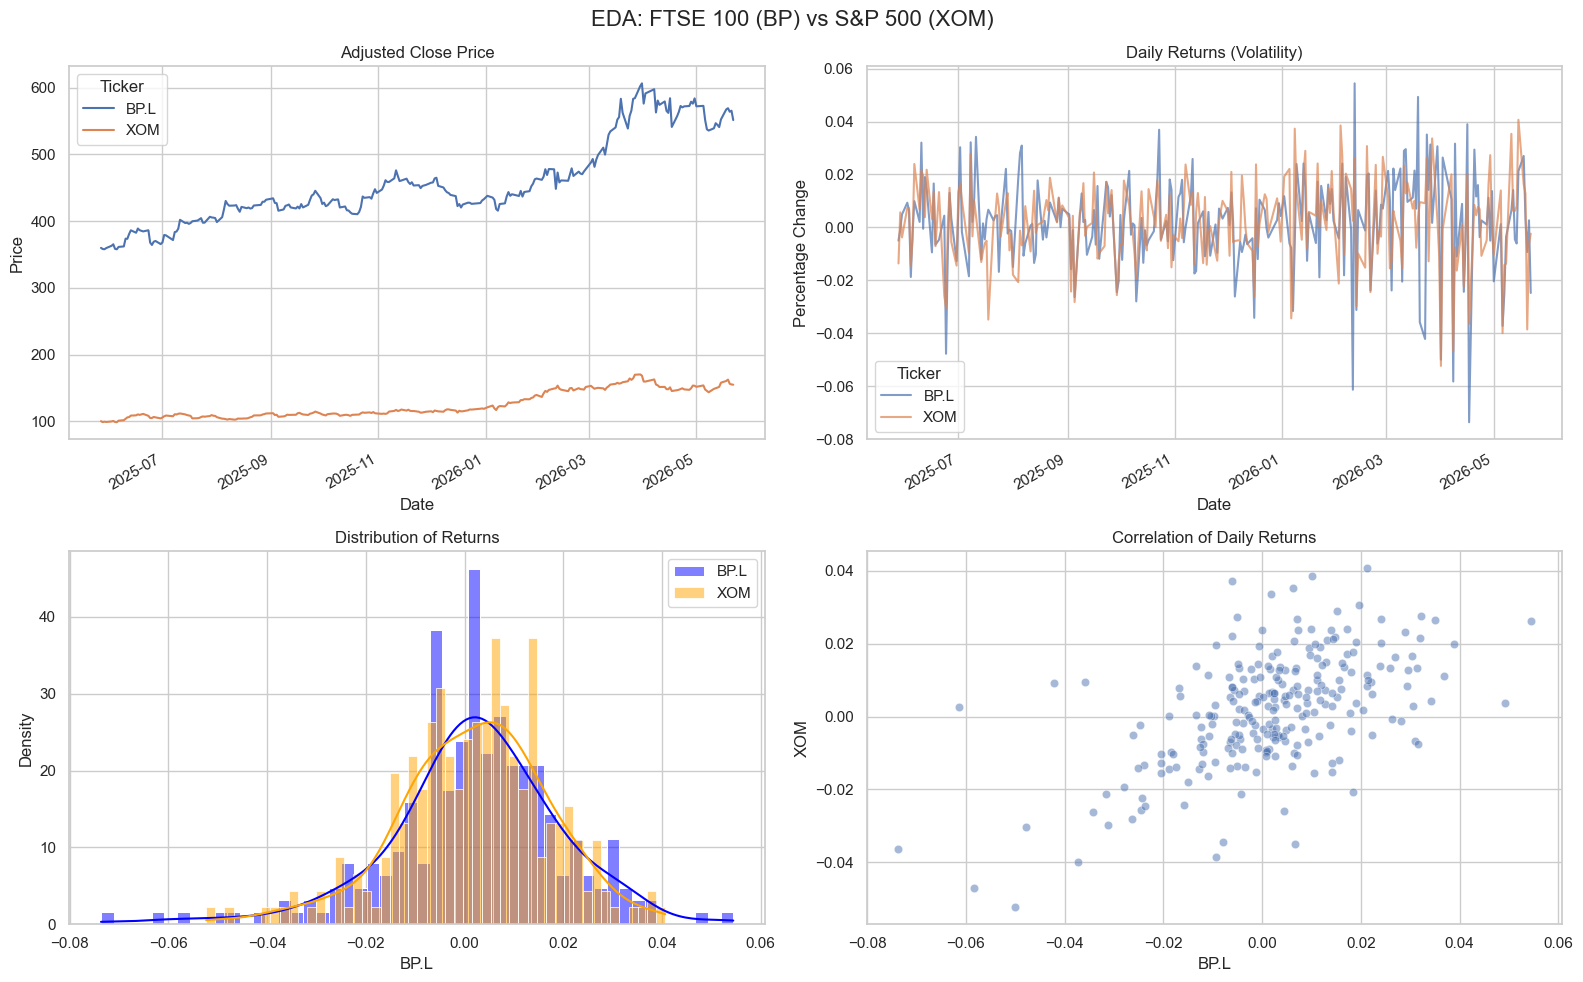

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA: FTSE 100 (BP) vs S&P 500 (XOM)', fontsize=16)

# 1. Absolute Price History
clean_data.plot(ax=axes[0, 0], title="Adjusted Close Price")
axes[0, 0].set_ylabel("Price")

# 2. Daily Returns (Volatility)
returns.plot(ax=axes[0, 1], title="Daily Returns (Volatility)", alpha=0.7)
axes[0, 1].set_ylabel("Percentage Change")

# 3. Distribution (Histogram)
sns.histplot(returns['BP.L'], bins=50, kde=True, ax=axes[1, 0], color='blue', label='BP.L', stat="density")
sns.histplot(returns['XOM'], bins=50, kde=True, ax=axes[1, 0], color='orange', label='XOM', stat="density")
axes[1, 0].set_title("Distribution of Returns")
axes[1, 0].legend()

# 4. Correlation
sns.scatterplot(data=returns, x='BP.L', y='XOM', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title("Correlation of Daily Returns")

plt.tight_layout()
plt.show()